In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.special import gamma
from scipy.optimize import brentq
import warnings
warnings.filterwarnings("ignore")

Solving kurtosis grid ...
  Converged: 100/100  | Lambda range: [0.239, 2.000]
Solving skewness grid ...
  Converged: 81/81  | Alpha range: [0.3653, 0.6347]
  Lambda used: [np.float64(0.2)]
  Implied kurtosis range: [1959.30, 2376.22]


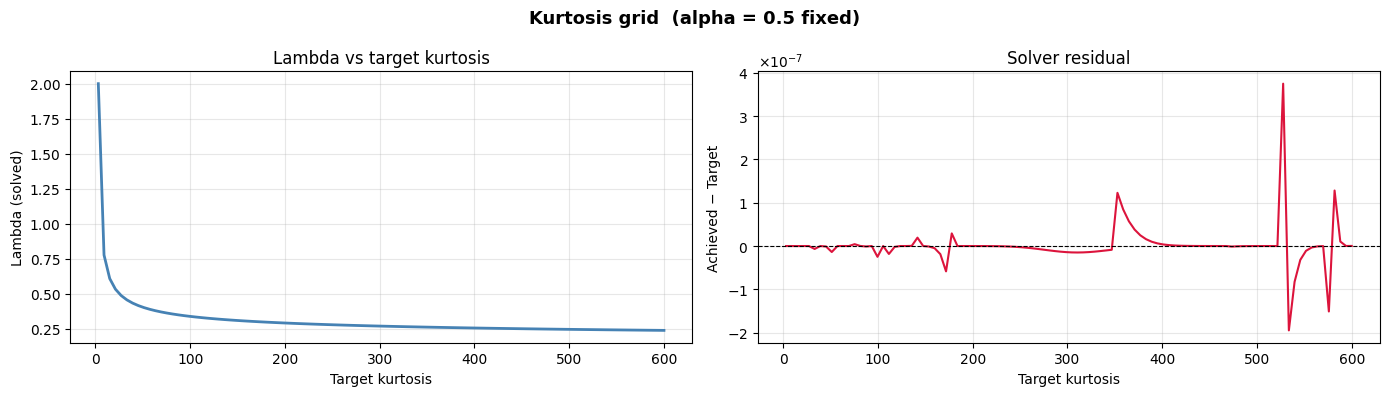

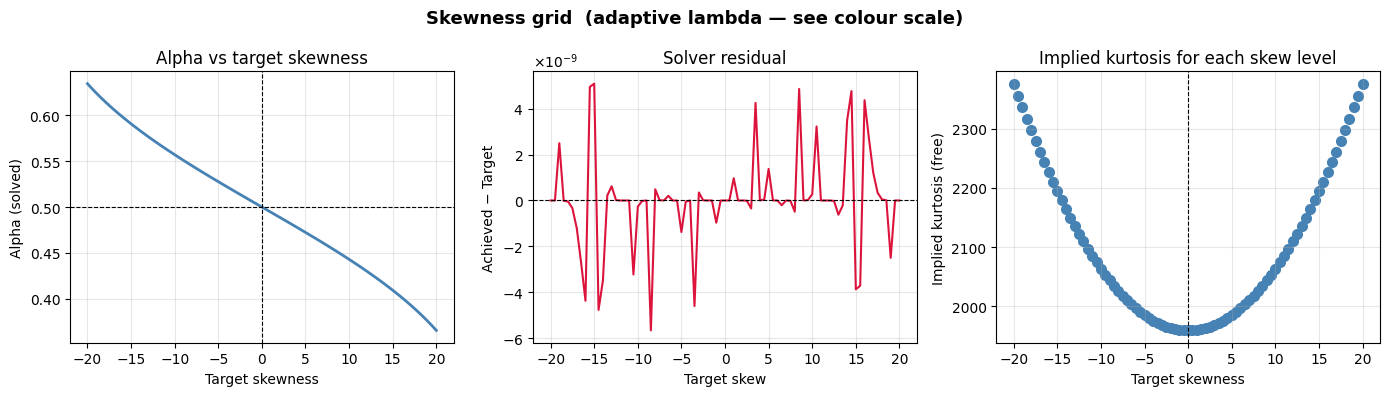

,target_skew,lam,alpha,achieved_skew,achieved_kurt,converged


In [2]:

# %% Parameters — edit freely
SKEW_GRID  = np.linspace(-20.0, 20.0, 81)   # target skewness values
KURT_GRID  = np.linspace(3.0, 600.0, 100)   # target kurtosis values
                                              # (raw 4th standardised moment; 3 = Normal)

ALPHA_KURTOSIS = 0.5    # fixed alpha for the kurtosis grid (symmetric)

# Skewness solver: for each target we try lambdas in descending order and
# use the first one for which brentq brackets a sign change on alpha.
# Smaller lambda → heavier tails → wider achievable |skew| range.
#LAMBDA_LADDER = [2.0, 1.5, 1.2, 1.0, 0.8, 0.6, 0.5, 0.4, 0.3, 0.25, 0.2]
LAMBDA_LADDER = [ 0.2]

# Solver search bounds
ALPHA_BOUNDS  = (1e-4, 1 - 1e-4)   # alpha ∈ (0, 1)
LAMBDA_BOUNDS = (0.15, 6.0)        # lambda > 0; small λ → heavy tails → high kurt

# %% APD moment engine (reused from Komunjer / user code)

def _delta(alpha: float, lam: float) -> float:
    """Scale constant δ of the APD."""
    num = 2.0 * (alpha ** lam) * ((1.0 - alpha) ** lam)
    den = (alpha ** lam) + ((1.0 - alpha) ** lam)
    return num / den


def raw_moment(k: int, alpha: float, lam: float) -> float:
    """k-th raw moment of the APD(alpha, lambda)."""
    d   = _delta(alpha, lam)
    M_k = (1.0 - alpha) ** (k + 1) + ((-1) ** k) * (alpha ** (k + 1))
    G_k = gamma((k + 1) / lam) / (d ** (k / lam) * gamma(1.0 / lam))
    return G_k * M_k


def apd_moments(alpha: float, lam: float) -> tuple[float, float]:
    m1, m2, m3, m4 = (raw_moment(k, alpha, lam) for k in range(1, 5))

    var  = m2 - m1 ** 2
    sd   = np.sqrt(var)
    mu3  = m3 - 3 * m1 * m2 + 2 * m1 ** 3
    mu4  = m4 - 4 * m1 * m3 + 6 * m1 ** 2 * m2 - 3 * m1 ** 4

    skew = mu3 / sd ** 3
    kurt = mu4 / sd ** 4          # raw kurtosis (3 = Normal)
    return skew, kurt

# %% Kurtosis grid solver
# alpha = 0.5 fixed; find lambda such that kurtosis(0.5, lambda) = target_kurt

def _kurt_residual_kurtgrid(lam: float, target_kurt: float) -> float:
    _, k = apd_moments(ALPHA_KURTOSIS, lam)
    return k - target_kurt


def solve_lambda_for_kurt(target_kurt: float) -> dict:
    result = dict(target_kurt=target_kurt, alpha=ALPHA_KURTOSIS,
                  lam=np.nan, achieved_skew=np.nan,
                  achieved_kurt=np.nan, converged=False)
    try:
        lo, hi = LAMBDA_BOUNDS
        f_lo = _kurt_residual_kurtgrid(lo, target_kurt)
        f_hi = _kurt_residual_kurtgrid(hi, target_kurt)
        if f_lo * f_hi > 0:
            # No sign change → target outside achievable range for these bounds
            return result
        lam_opt = brentq(_kurt_residual_kurtgrid, lo, hi,
                         args=(target_kurt,), xtol=1e-10, rtol=1e-10)
        skew_a, kurt_a = apd_moments(ALPHA_KURTOSIS, lam_opt)
        result.update(lam=lam_opt, achieved_skew=skew_a,
                      achieved_kurt=kurt_a, converged=True)
    except Exception:
        pass
    return result


print("Solving kurtosis grid ...")
kurt_records = [solve_lambda_for_kurt(k) for k in KURT_GRID]
kurt_df = pd.DataFrame(kurt_records)
n_ok  = kurt_df["converged"].sum()
print(f"  Converged: {n_ok}/{len(kurt_df)}  "
      f"| Lambda range: [{kurt_df['lam'].min():.3f}, {kurt_df['lam'].max():.3f}]")

def _skew_residual(alpha: float, lam: float, target_skew: float) -> float:
    s, _ = apd_moments(alpha, lam)
    return s - target_skew


def solve_alpha_for_skew(target_skew: float) -> dict:
    """
    Find (alpha, lambda) such that APD(alpha, lambda) has skewness = target_skew.

    Walks down LAMBDA_LADDER; for each lambda tries brentq on alpha ∈ ALPHA_BOUNDS.
    Returns on the first lambda that brackets a sign change (largest lambda that
    works → lightest feasible tails for the given target).
    Kurtosis is unconstrained (free).

    Keys: target_skew, lam, alpha, achieved_skew, achieved_kurt, converged
    """
    result = dict(target_skew=target_skew, lam=np.nan, alpha=np.nan,
                  achieved_skew=np.nan, achieved_kurt=np.nan, converged=False)

    lo, hi = ALPHA_BOUNDS
    for lam in LAMBDA_LADDER:
        try:
            f_lo = _skew_residual(lo, lam, target_skew)
            f_hi = _skew_residual(hi, lam, target_skew)
            if f_lo * f_hi > 0:
                # No sign change for this lambda → try next (smaller) one
                continue
            alpha_opt = brentq(_skew_residual, lo, hi,
                               args=(lam, target_skew),
                               xtol=1e-10, rtol=1e-10)
            skew_a, kurt_a = apd_moments(alpha_opt, lam)
            result.update(lam=lam, alpha=alpha_opt, achieved_skew=skew_a,
                          achieved_kurt=kurt_a, converged=True)
            return result          # found — stop at largest feasible lambda
        except Exception:
            continue               # numerical issue; try next lambda

    return result                  # all lambdas exhausted without convergence


print("Solving skewness grid ...")
skew_records = [solve_alpha_for_skew(s) for s in SKEW_GRID]
skew_df = pd.DataFrame(skew_records)
n_ok = skew_df["converged"].sum()
print(f"  Converged: {n_ok}/{len(skew_df)}  "
      f"| Alpha range: [{skew_df['alpha'].min():.4f}, {skew_df['alpha'].max():.4f}]")
print(f"  Lambda used: {sorted(skew_df['lam'].dropna().unique())}")
print(f"  Implied kurtosis range: "
      f"[{skew_df['achieved_kurt'].min():.2f}, {skew_df['achieved_kurt'].max():.2f}]")

# %% Plot — Kurtosis grid
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(
    f"Kurtosis grid  (alpha = {ALPHA_KURTOSIS} fixed)",
    fontsize=13, fontweight="bold"
)

df_ok = kurt_df[kurt_df["converged"]]

ax = axes[0]
ax.plot(df_ok["target_kurt"], df_ok["lam"], color="steelblue", lw=2)
ax.set_xlabel("Target kurtosis")
ax.set_ylabel("Lambda (solved)")
ax.set_title("Lambda vs target kurtosis")
ax.grid(True, alpha=0.3)

ax = axes[1]
error = df_ok["achieved_kurt"] - df_ok["target_kurt"]
ax.plot(df_ok["target_kurt"], error, color="crimson", lw=1.5)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Target kurtosis")
ax.set_ylabel("Achieved − Target")
ax.set_title("Solver residual")
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %% Plot — Skewness grid
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(
    "Skewness grid  (adaptive lambda — see colour scale)",
    fontsize=13, fontweight="bold"
)

df_ok = skew_df[skew_df["converged"]].copy()

ax = axes[0]
sc = ax.plot(df_ok["target_skew"], df_ok["alpha"], color="steelblue", lw=2)
ax.axvline(0,   color="black", lw=0.8, ls="--")
ax.axhline(0.5, color="black", lw=0.8, ls="--", label="alpha=0.5 (symmetric)")
ax.set_xlabel("Target skewness")
ax.set_ylabel("Alpha (solved)")
ax.set_title("Alpha vs target skewness")
ax.grid(True, alpha=0.3)

ax = axes[1]
error = df_ok["achieved_skew"] - df_ok["target_skew"]
ax.plot(df_ok["target_skew"], error, color="crimson", lw=1.5)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Target skew")
ax.set_ylabel("Achieved − Target")
ax.set_title("Solver residual")
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.grid(True, alpha=0.3)

ax = axes[2]
sc = ax.scatter(df_ok["target_skew"], df_ok["achieved_kurt"], color="steelblue", lw=2)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Target skewness")
ax.set_ylabel("Implied kurtosis (free)")
ax.set_title("Implied kurtosis for each skew level")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %% Quick summary tables
kurt_df[kurt_df.converged==False]
skew_df[skew_df.converged==False]

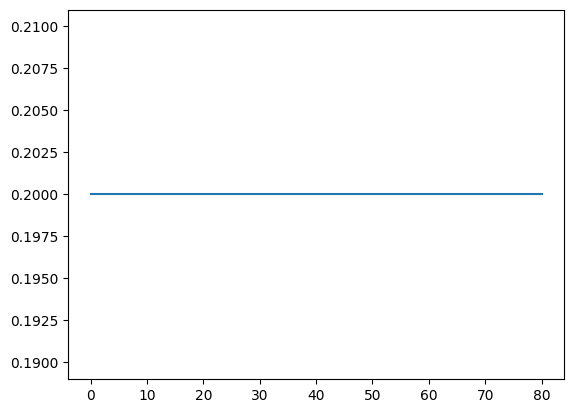

In [3]:
plt.plot(skew_df.lam)

In [3]:
def hansen_skewt_moments(df: float, lam: float) -> tuple[float, float]:
    """
    Returns exact theoretical (skewness, kurtosis) for the Hansen Skew-T
    distribution, using formulas from Jondeau and Rockinger (2003).
    """
    if df <= 4.0:
        return np.nan, np.nan
    nu=df
    eta=lam
    c = gamma((nu + 1) / 2) / (
            np.sqrt(np.pi * (nu - 2)) * gamma(nu / 2)
        )
    a = 4.0 * eta * c * (nu - 2) / (nu - 1)
    b = np.sqrt(1.0 + 3.0 * eta**2 - a**2)
    
    m2 = 1.0 + 3.0 * eta**2
    m3 = (16.0 * c * eta * (1.0 + eta**2) * (nu - 2)**2) / ((nu - 1) * (nu - 3))
    m4 = 3.0 * ((nu - 2) / (nu - 4)) * (1.0 + 10.0*eta**2 + 5.0*eta**4)

    skew = (m3 - 3*a*m2 + 2*a**3) / (b**3)
    kurt = (m4 - 4*a*m3 + 6*a**2*m2 - 3*a**4) / (b**4)
            
    return skew, kurt

In [5]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.ticker as ticker
# from scipy.special import gammaln
# from scipy.optimize import brentq

# # %% Parameters — edit freely
# SKEW_GRID  = np.linspace(-3.0, 3.0, 81)     # Target skewness (Skew-T has limits; ±3 is realistic)
# KURT_GRID  = np.linspace(3.1, 100.0, 100)   # Target kurtosis (Must be > 3 for Skew-T)

# LAMBDA_KURTOSIS = 0.0    # Fixed lam for kurtosis grid (0 = symmetric)

# # Skewness solver ladder
# # Smaller df -> heavier tails -> wider achievable |skew| range.
# DF_LADDER = [30.0, 20.0, 15.0, 10.0, 8.0, 6.0, 5.0, 4.5, 4.1]

# # Solver search bounds
# LAMBDA_BOUNDS = (-0.999, 0.999)    # lam parameter is strictly inside (-1, 1)
# DF_BOUNDS = (4.001, 1000.0)        # df > 4 bounds (needed for 4th moment)

# # %% Hansen Skew-T moment engine
# def hansen_skewt_moments(df: float, lam: float) -> tuple[float, float]:
#     """
#     Returns exact theoretical (skewness, kurtosis) for the Hansen Skew-T.
#     Uses log-gamma to prevent float64 overflow at high DF.
#     """
#     if df <= 4.0:
#         return np.nan, np.nan
        
#     # log-gamma for numerical stability at high df
#     log_c = gammaln((df + 1.0) / 2.0) - gammaln(df / 2.0) - 0.5 * np.log(np.pi * (df - 2.0))
#     c = np.exp(log_c)
    
#     a = 4.0 * lam * c * ((df - 2.0) / (df - 1.0))
    
#     m2 = 1.0 + 3.0 * lam**2
#     m3 = 16.0 * c * lam * (1.0 + lam**2) * ((df - 2.0)**2 / ((df - 1.0) * (df - 3.0)))
#     m4 = (3.0 * (df - 2.0) / (df - 4.0)) * (1.0 + 10.0 * lam**2 + 5.0 * lam**4)
    
#     # Variance
#     var = m2 - a**2
    
#     # Central moments
#     mu3 = m3 - 3.0 * a * m2 + 2.0 * a**3
#     mu4 = m4 - 4.0 * a * m3 + 6.0 * a**2 * m2 - 3.0 * a**4
    
#     # Standardized Skewness and Kurtosis (This was missing before!)
#     skew = mu3 / (var ** 1.5)
#     kurt = mu4 / (var ** 2.0)
    
#     return skew, kurt

# # %% Kurtosis grid solver
# def _kurt_residual_kurtgrid(df: float, target_kurt: float) -> float:
#     _, k = hansen_skewt_moments(df, LAMBDA_KURTOSIS)
#     return k - target_kurt

# def solve_df_for_kurt(target_kurt: float) -> dict:
#     result = dict(target_kurt=target_kurt, lam=LAMBDA_KURTOSIS,
#                   df=np.nan, achieved_skew=np.nan,
#                   achieved_kurt=np.nan, converged=False)
#     try:
#         lo, hi = DF_BOUNDS
#         f_lo = _kurt_residual_kurtgrid(lo, target_kurt)
#         f_hi = _kurt_residual_kurtgrid(hi, target_kurt)
#         if f_lo * f_hi > 0:
#             return result
#         df_opt = brentq(_kurt_residual_kurtgrid, lo, hi,
#                         args=(target_kurt,), xtol=1e-10, rtol=1e-10)
#         skew_a, kurt_a = hansen_skewt_moments(df_opt, LAMBDA_KURTOSIS)
#         result.update(df=df_opt, achieved_skew=skew_a,
#                       achieved_kurt=kurt_a, converged=True)
#     except Exception:
#         pass
#     return result

# print("Solving kurtosis grid ...")
# kurt_records = [solve_df_for_kurt(k) for k in KURT_GRID]
# kurt_df = pd.DataFrame(kurt_records)
# n_ok  = kurt_df["converged"].sum()
# print(f"  Converged: {n_ok}/{len(kurt_df)}  "
#       f"| DF range: [{kurt_df['df'].min():.3f}, {kurt_df['df'].max():.3f}]")

# # %% Skewness grid solver
# def _skew_residual(lam: float, df: float, target_skew: float) -> float:
#     s, _ = hansen_skewt_moments(df, lam)
#     return s - target_skew

# def solve_lam_for_skew(target_skew: float) -> dict:
#     result = dict(target_skew=target_skew, df=np.nan, lam=np.nan,
#                   achieved_skew=np.nan, achieved_kurt=np.nan, converged=False)

#     lo, hi = LAMBDA_BOUNDS
#     for df in DF_LADDER:
#         try:
#             f_lo = _skew_residual(lo, df, target_skew)
#             f_hi = _skew_residual(hi, df, target_skew)
#             if f_lo * f_hi > 0:
#                 continue
#             lam_opt = brentq(_skew_residual, lo, hi,
#                              args=(df, target_skew),
#                              xtol=1e-10, rtol=1e-10)
#             skew_a, kurt_a = hansen_skewt_moments(df, lam_opt)
#             result.update(df=df, lam=lam_opt, achieved_skew=skew_a,
#                           achieved_kurt=kurt_a, converged=True)
#             return result 
#         except Exception:
#             continue
#     return result

# print("Solving skewness grid ...")
# skew_records = [solve_lam_for_skew(s) for s in SKEW_GRID]
# skew_df = pd.DataFrame(skew_records)
# n_ok = skew_df["converged"].sum()
# print(f"  Converged: {n_ok}/{len(skew_df)}  "
#       f"| Lambda range: [{skew_df['lam'].min():.4f}, {skew_df['lam'].max():.4f}]")
# print(f"  DF used: {sorted(skew_df['df'].dropna().unique())}")
# print(f"  Implied kurtosis range: "
#       f"[{skew_df['achieved_kurt'].min():.2f}, {skew_df['achieved_kurt'].max():.2f}]")

# # %% Plot — Kurtosis grid
# fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# fig.suptitle(f"Kurtosis grid (lambda = {LAMBDA_KURTOSIS} fixed)", fontsize=13, fontweight="bold")

# df_ok = kurt_df[kurt_df["converged"]]
# ax = axes[0]
# ax.plot(df_ok["target_kurt"], df_ok["df"], color="steelblue", lw=2)
# ax.set_xlabel("Target kurtosis")
# ax.set_ylabel("DF (solved)")
# ax.set_title("DF vs target kurtosis")
# ax.grid(True, alpha=0.3)

# ax = axes[1]
# error = df_ok["achieved_kurt"] - df_ok["target_kurt"]
# ax.plot(df_ok["target_kurt"], error, color="crimson", lw=1.5)
# ax.axhline(0, color="black", lw=0.8, ls="--")
# ax.set_xlabel("Target kurtosis")
# ax.set_ylabel("Achieved − Target")
# ax.set_title("Solver residual")
# ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # %% Plot — Skewness grid
# fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# fig.suptitle("Skewness grid (adaptive df)", fontsize=13, fontweight="bold")

# df_ok = skew_df[skew_df["converged"]].copy()

# ax = axes[0]
# sc = ax.plot(df_ok["target_skew"], df_ok["lam"], color="steelblue", lw=2)
# ax.axvline(0,   color="black", lw=0.8, ls="--")
# ax.axhline(0.0, color="black", lw=0.8, ls="--", label="lam=0.0 (symmetric)")
# ax.set_xlabel("Target skewness")
# ax.set_ylabel("Lambda (solved)")
# ax.set_title("Lambda vs target skewness")
# ax.grid(True, alpha=0.3)

# ax = axes[1]
# error = df_ok["achieved_skew"] - df_ok["target_skew"]
# ax.plot(df_ok["target_skew"], error, color="crimson", lw=1.5)
# ax.axhline(0, color="black", lw=0.8, ls="--")
# ax.set_xlabel("Target skew")
# ax.set_ylabel("Achieved − Target")
# ax.set_title("Solver residual")
# ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
# ax.grid(True, alpha=0.3)

# ax = axes[2]
# sc = ax.scatter(df_ok["target_skew"], df_ok["achieved_kurt"], color="steelblue", lw=2)
# ax.axvline(0, color="black", lw=0.8, ls="--")
# ax.set_xlabel("Target skewness")
# ax.set_ylabel("Implied kurtosis (free)")
# ax.set_title("Implied kurtosis for each skew level")
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

In [6]:
from core.dgp import APDInnov, IIDProcess, SkewTInnov

m = IIDProcess(SkewTInnov(df=5.0, eta=0.5)).calibrate_params(mu=0.15, sigma=1.0)
#m = IIDProcess(APDInnov(alpha=0.5, lam=0.238905)).calibrate_params(mu=0.15, sigma=1.0)

In [7]:
m.get_theo_moments()

{'skew': np.float64(1.8404291805022661),
 'exc_kurt': np.float64(12.650189652678161),
 'rho': 0,
 'nu': 5.0,
 'mean': 0.15,
 'sigma': 1.0}

In [8]:
hansen_skewt_moments(50,0)

(np.float64(0.0), np.float64(3.1304347826086953))

In [9]:
rng = np.random.default_rng(42)
sample = m.simulate(100000, rng)

In [10]:
from scipy import stats

stats.kurtosis(sample, fisher=False,),stats.skew(sample)

(np.float64(12.06390083944799), np.float64(1.7705167330036287))

In [4]:
MEAN_GRID  = np.linspace(0.0, 5.0, 81)
STD_GRID  = np.linspace(0.0, 5.0, 81)

In [5]:
mean_df = pd.DataFrame([dict(target_mean=mean, lam=2, alpha=0.5, achieved_mean=mean, converged=True) 
                        for mean in MEAN_GRID])
std_df = pd.DataFrame([dict(target_std=std, lam=2, alpha=0.5, achieved_std=std, converged=True) 
                        for std in STD_GRID])


In [6]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import warnings

from core.dgp import APDInnov, IIDProcess, SkewTInnov

In [7]:

import statsmodels.formula.api as smf
from scipy import stats as scipy_stats
warnings.filterwarnings("ignore")

SEED        = 42
N_SIMS      = 1000
T           = 50

_SAMPLE_ESTIMATORS = {
    "mean": lambda x: np.mean(x),
    "std": lambda x: np.std(x, ddof=1),
    "skew": lambda x: scipy_stats.skew(x, bias=False),
    "kurt": lambda x: scipy_stats.kurtosis(x, fisher=False, bias=False),  # raw kurt
}
_TARGET_COLS = {
    "mean": "target_mean",
    "std":  "target_std",
    "skew": "target_skew",
    "kurt": "target_kurt",
}
 
 
def simulate_panel(
    param:  str,                  # "skew" or "kurt"
    grid_df: pd.DataFrame,        # skew_df or kurt_df (converged rows only)
    n_sims: int = N_SIMS,
    T:      int = T,
    seed:   int = SEED,
) -> pd.DataFrame:
    """
    For every (alpha, lam) row in grid_df, draw n_sims independent samples
    of length T from APD(alpha, lam) and compute the sample moment estimator.
 
    Parameters
    ----------
    param    : which moment to study — "skew" or "kurt"
    grid_df  : parameter grid DataFrame (output of solve_* functions,
               filtered to converged=True).  Must contain columns
               'alpha', 'lam', and the relevant target column.
    n_sims   : number of Monte-Carlo replications per grid point
    T        : sample length for each replication
    seed     : RNG seed
 
    Returns
    -------
    Tidy DataFrame with columns:
        sim_id          replication index
        true_mom        true (population) value of the moment
        sample_mom      sample estimator value
        estimation_err  sample_mom − true_mom
        sq_err          estimation_err²
    """
    if param not in _SAMPLE_ESTIMATORS:
        raise ValueError(f"param must be one of {list(_SAMPLE_ESTIMATORS)}; got '{param}'")
 
    target_col = _TARGET_COLS[param]
    estimator  = _SAMPLE_ESTIMATORS[param]
    rng        = np.random.default_rng(seed)
 
    rows = []
    for _, row in grid_df.iterrows():
        true_val = float(row[target_col])
        dgp = IIDProcess(APDInnov(alpha=row["alpha"], lam=row["lam"])).calibrate_params(
            mu=true_val if param=="mean" else 0.0, 
            sigma=true_val if param=="std" else 1.0
        )
 
        for i in range(n_sims):
            x = dgp.simulate(T, rng)
            rows.append({
                "sim_id":    i,
                "true_mom":  round(true_val, 6),
                "sample_mom": float(estimator(x)),
            })
 
    panel = pd.DataFrame(rows)
    panel["estimation_err"] = panel["sample_mom"] - panel["true_mom"]
    panel["sq_err"]         = panel["estimation_err"] ** 2
    return panel
 
 

def aggregate_panel(panel: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse the simulation panel to one row per true-moment level.
    Reports bias, variance, MSE, and RMSE of the estimator.
    """
    agg = (
        panel
        .groupby("true_mom")
        .agg(
            mean_estimate=("sample_mom", "mean"),
            var_estimate =("sample_mom", "var"),
            std_estimate =("sample_mom", "std"),
            q25          =("sample_mom", lambda s: s.quantile(0.05)),
            q75          =("sample_mom", lambda s: s.quantile(0.95)),
            mse          =("sq_err",     "mean"),
            n_sims       =("sample_mom", "count"),
        )
        .reset_index()
    )
    agg["bias"] = agg["mean_estimate"] - agg["true_mom"]
    agg["rmse"] = np.sqrt(agg["mse"])
    return agg
 
 

def get_bailey_regressions(panel: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    # 1. Calcular el error individual por cada simulación
    df_reg = panel.copy()
    df_reg['er'] = df_reg['sample_mom'] - df_reg['true_mom']
    df_reg['er2'] = df_reg['er'] ** 2
    
    # 2. Correr los modelos sobre los miles/millones de filas
    model_er = smf.ols("er ~ 1 + true_mom + I(true_mom**2)", data=df_reg).fit()
    model_er2 = smf.ols("er2 ~ 1 + true_mom + I(true_mom**2)", data=df_reg).fit()
    
    # ... (El resto del código de extracción es exactamente igual que el anterior)
    
    terms = ['Intercept', 'true_mom', 'I(true_mom ** 2)']
    results = []
    
    for degree, term in enumerate(terms):
        results.append({
            "Degree": degree,
            "er_δ": round(model_er.params[term], 4),
            "er_Prob": round(model_er.pvalues[term], 4),
            "er2_θ": round(model_er2.params[term], 4),
            "er2_Prob": round(model_er2.pvalues[term], 4)
        })
        
    summary_table = pd.DataFrame(results)
    r2_scores = {
        "adj_R2_er": round(model_er.rsquared_adj, 4),
        "adj_R2_er2": round(model_er2.rsquared_adj, 4)
    }
    
    return summary_table, r2_scores

def plot_experiment(
    agg_df:     pd.DataFrame,
    param_name: str,
    save_prefix: str = None,
) -> None:
    """
    Two diagnostic plots for a moment-estimator experiment.
 
    Parameters
    ----------
    agg_df      : output of aggregate_panel()
    param_name  : human-readable label for axis titles / suptitle
    save_prefix : optional filename prefix for saving to disk
    """
    x     = agg_df["true_mom"].values
    ymean = agg_df["mean_estimate"].values
    yq25  = agg_df["q25"].values
    yq75  = agg_df["q75"].values
    yvar  = agg_df["var_estimate"].values
 
    # ── Plot 1: True vs Mean Estimated ───────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))
 
    # IQR band (respects asymmetry, always on the correct side of the estimate)
    ax.fill_between(x, yq25, yq75,
                    alpha=0.20, color="steelblue", label="Quantil band [Q05, Q95]")
 
    # Mean estimate
    ax.plot(x, ymean, color="steelblue", lw=2, marker="o", ms=3,
            label="Mean estimate")
 
    # 45-degree reference line spanning the full range of x
    ref_lo = min(x.min(), ymean.min())
    ref_hi = max(x.max(), ymean.max())
    ax.plot([ref_lo, ref_hi], [ref_lo, ref_hi],
            color="black", lw=1.2, ls="--", label="45° line (perfect)")
 
    ax.set_xlabel(f"True {param_name}")
    ax.set_ylabel(f"Mean estimated {param_name}")
    ax.set_title(f"{param_name} estimator — True vs Mean Estimated\n"
                 f"(T={T}, N={N_SIMS} sims per cell)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_prefix:
        fname = f"{save_prefix}_truevsmean.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        print(f"Saved: {fname}")
    plt.show()
 
    # ── Plot 2: Variance vs True moment ──────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))
 
    ax.plot(x, yvar, color="darkorange", lw=2, marker="o", ms=3,
            label="Estimator variance")
 
    ax.set_xlabel(f"True {param_name}")
    ax.set_ylabel(f"Var(estimated {param_name})")
    ax.set_title(f"{param_name} estimator — Variance vs True Level\n"
                 f"(T={T}, N={N_SIMS} sims per cell)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_prefix:
        fname = f"{save_prefix}_variance.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        print(f"Saved: {fname}")
    plt.show()


Saved: apd_est_mean_truevsmean.png


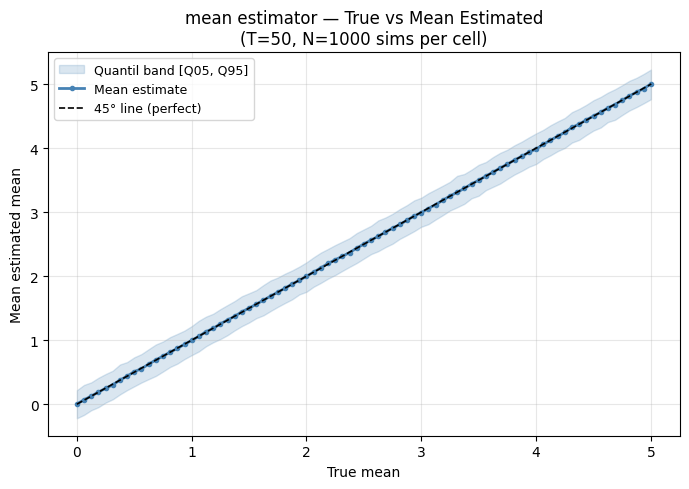

Saved: apd_est_mean_variance.png


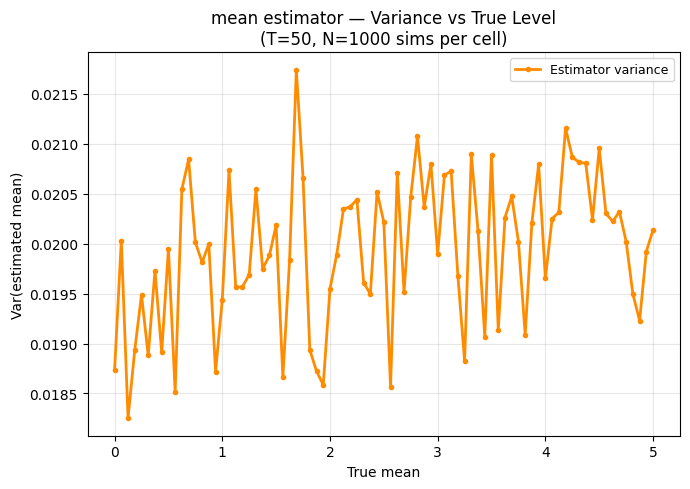

In [8]:
mean_panel = simulate_panel("mean", mean_df[mean_df["converged"]])
mean_agg   = aggregate_panel(mean_panel)
plot_experiment(mean_agg, param_name="mean", save_prefix="apd_est_mean")
#mean_reg   = get_estimation_error_models(mean_agg)

In [9]:
get_bailey_regressions(mean_panel)

(   Degree    er_δ  er_Prob   er2_θ  er2_Prob
 0       0  0.0004   0.7732  0.0192    0.0000
 1       1 -0.0002   0.8804  0.0005    0.0695
 2       2  0.0000   0.9781 -0.0001    0.2362,
 {'adj_R2_er': np.float64(-0.0), 'adj_R2_er2': np.float64(0.0001)})

Saved: apd_est_std_truevsmean.png


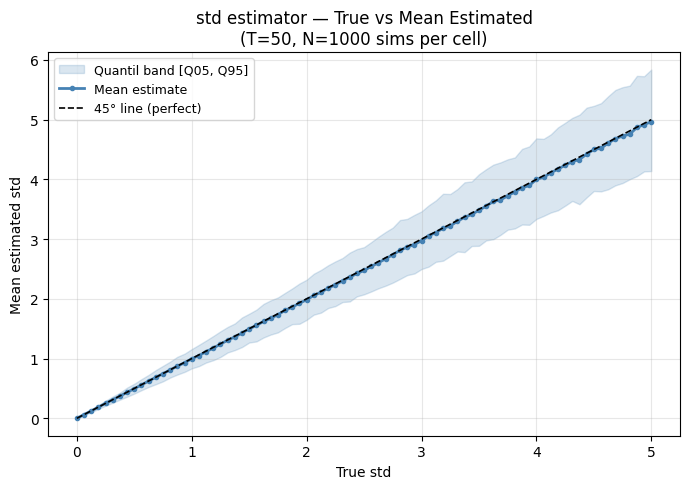

Saved: apd_est_std_variance.png


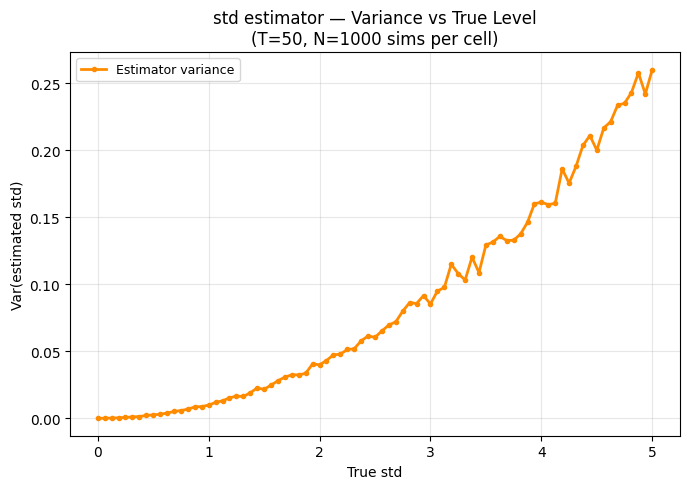

In [10]:
std_panel = simulate_panel("std", std_df[std_df["converged"]])
std_agg   = aggregate_panel(std_panel)
plot_experiment(std_agg, param_name="std", save_prefix="apd_est_std")
#std_reg   = get_estimation_error_models(std_agg)

In [11]:
get_bailey_regressions(std_panel)


(   Degree    er_δ  er_Prob   er2_θ  er2_Prob
 0       0 -0.0002   0.9552  0.0016    0.3528
 1       1 -0.0059   0.0334 -0.0023    0.1352
 2       2  0.0003   0.6090  0.0107    0.0000,
 {'adj_R2_er': np.float64(0.0005), 'adj_R2_er2': np.float64(0.1815)})

Saved: apd_est_skew_truevsmean.png


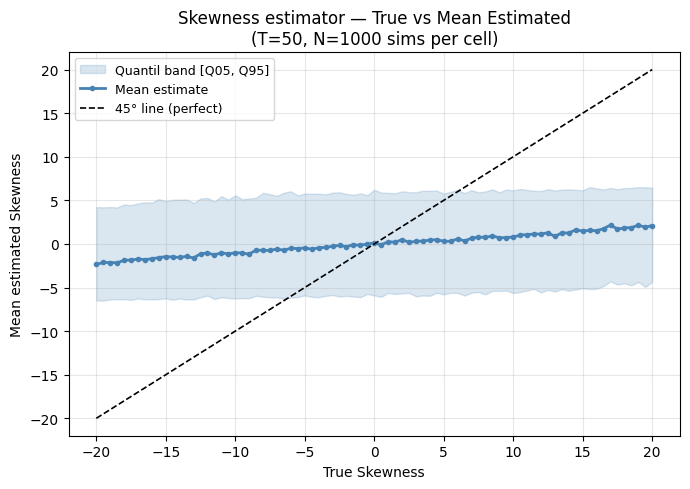

Saved: apd_est_skew_variance.png


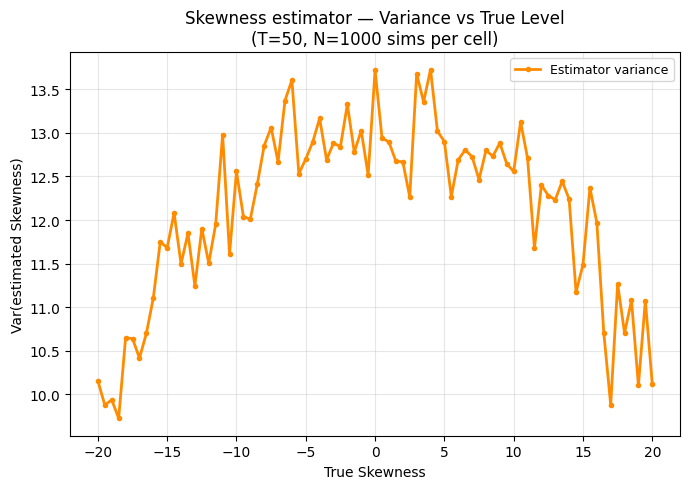

In [12]:
skew_panel = simulate_panel("skew", skew_df[skew_df["converged"]])
skew_agg   = aggregate_panel(skew_panel)
plot_experiment(skew_agg, param_name="Skewness", save_prefix="apd_est_skew")
#skew_reg   = get_estimation_error_models(skew_agg)

In [14]:
get_bailey_regressions(skew_panel)

(   Degree    er_δ  er_Prob    er2_θ  er2_Prob
 0       0 -0.0187   0.3089  14.3316       0.0
 1       1 -0.8971   0.0000   0.0958       0.0
 2       2 -0.0001   0.2508   0.7885       0.0,
 {'adj_R2_er': np.float64(0.9008), 'adj_R2_er2': np.float64(0.6126)})

Saved: apd_est_kurt_truevsmean.png


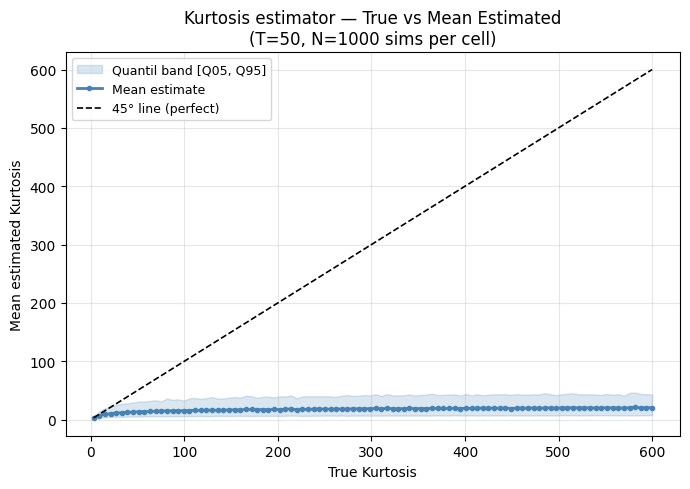

Saved: apd_est_kurt_variance.png


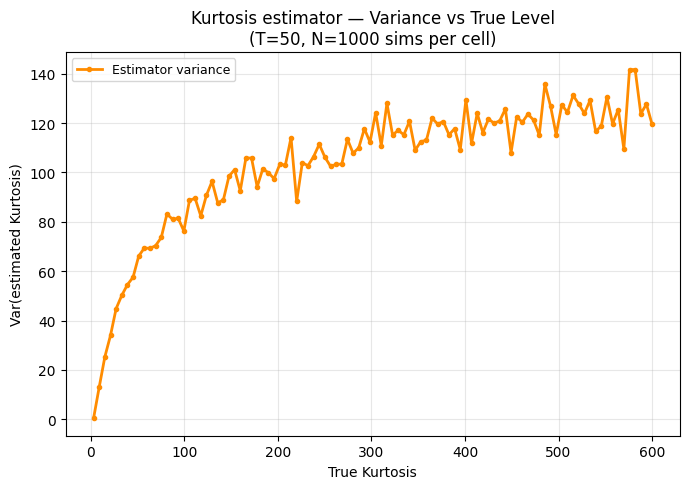

In [15]:
kurt_panel = simulate_panel("kurt", kurt_df[kurt_df["converged"]])
kurt_agg   = aggregate_panel(kurt_panel)
plot_experiment(kurt_agg, param_name="Kurtosis", save_prefix="apd_est_kurt")
#kurt_reg   = get_estimation_error_models(kurt_agg)

In [16]:
get_bailey_regressions(kurt_panel)

(   Degree     er_δ  er_Prob     er2_θ  er2_Prob
 0       0  10.4304      0.0  608.6446       0.0
 1       1  -0.9584      0.0  -33.6916       0.0
 2       2  -0.0000      0.0    0.9877       0.0,
 {'adj_R2_er': np.float64(0.9965), 'adj_R2_er2': np.float64(0.995)})